In [200]:
from langchain.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.chains import RetrievalQA
from langchain_community.retrievers import BM25Retriever
# from langchain.document_loaders import PyMuPDFLoader
from langchain_community.document_loaders import PyPDFLoader

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, trim_messages
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages.utils import count_tokens_approximately


import warnings
warnings.filterwarnings("ignore")

In [201]:
## Load environment variables
load_dotenv()
os.environ["HF_TOKEN"]=os.getenv("HF_TOKEN")

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
os.environ['TAVILY_API_KEY'] = TAVILY_API_KEY

## chat client
llm = ChatGroq(groq_api_key=os.getenv("GROQ_API_KEY_3") ,model="openai/gpt-oss-120b", temperature=0)

embedding_model=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


## Doctor's Database

In [202]:
doctors_db = [
    {
        "name": "Dr. Janet Dyne",
        "specialization": "Endocrinology (Diabetes Care)",
        "available_timings": "10:00 AM - 1:00 PM",
        "location": "City Health Clinic",
        "contact": "janet.dyne@healthclinic.com"
    },
    {
        "name": "Dr. Don Blake",
        "specialization": "Cardiology (Heart Specialist)",
        "available_timings": "2:00 PM - 5:00 PM",
        "location": "Metro Cardiac Center",
        "contact": "don.blake@metrocardiac.com"
    },
    {
        "name": "Dr. Susan D'Souza",
        "specialization": "Oncology (Cancer Care)",
        "available_timings": "11:00 AM - 2:00 PM",
        "location": "Hope Cancer Institute",
        "contact": "susan.dsouza@hopecancer.org"
    },
    {
        "name": "Dr. Matt Murdock",
        "specialization": "Psychiatry (Mental Health)",
        "available_timings": "4:00 PM - 7:00 PM",
        "location": "Mind Care Center",
        "contact": "matt.murdock@mindcare.com"
    },
    {
        "name": "Dr. Dinah Lance",
        "specialization": "General Physician",
        "available_timings": "9:00 AM - 12:00 PM",
        "location": "Downtown Medical Center",
        "contact": "dinah.lance@downtownmed.com"
    }
]


## Doctor's Availability Slots

In [203]:
doctor_slots_db = {
    "Dr. Janet Dyne": {
        "slots": [
            {"time": "10:00 AM", "available": True},
            {"time": "10:30 AM", "available": True},
            {"time": "11:00 AM", "available": True},
            {"time": "11:30 AM", "available": True},
            {"time": "12:00 PM", "available": True}
        ]
    },

    "Dr. Don Blake": {
        "slots": [
            {"time": "2:00 PM", "available": True},
            {"time": "2:30 PM", "available": True},
            {"time": "3:00 PM", "available": True},
            {"time": "3:30 PM", "available": True},
            {"time": "4:00 PM", "available": True}
        ]
    },

    "Dr. Susan D'Souza": {
        "slots": [
            {"time": "11:00 AM", "available": True},
            {"time": "11:30 AM", "available": True},
            {"time": "12:00 PM", "available": True},
            {"time": "12:30 PM", "available": True},
            {"time": "1:00 PM", "available": True}
        ]
    },

    "Dr. Matt Murdock": {
        "slots": [
            {"time": "4:00 PM", "available": True},
            {"time": "4:30 PM", "available": True},
            {"time": "5:00 PM", "available": True},
            {"time": "5:30 PM", "available": True},
            {"time": "6:00 PM", "available": True}
        ]
    },

    "Dr. Dinah Lance": {
        "slots": [
            {"time": "9:00 AM", "available": True},
            {"time": "9:30 AM", "available": True},
            {"time": "10:00 AM", "available": True},
            {"time": "10:30 AM", "available": True},
            {"time": "11:00 AM", "available": True}
        ]
    }
}


## Maintains a list of conformed booking

In [204]:
booking_db = []

## Define the tools

In [210]:
# Web search setup
tavily_search = TavilySearchAPIWrapper()

@tool
def search_web(query: str, num_results=8) -> list:
    """Search the web for a query. Userful for general information or general news"""
    results = tavily_search.raw_results(query=query,
                                        max_results=num_results,
                                        search_depth='advanced',
                                        include_answer=False,
                                        include_raw_content=True)
    return results

# Recommend doctor based on the user's symptoms
@tool
def recommend_doctor(query: str) -> dict:
    """Recommend the most suitable doctor based on the user's symptoms."""

    doctors_list = str(doctors_db)

    # Use LLM reasoning to select the most appropriate doctor based on the query
    prompt = f"""
    You are an assistant helping recommend a doctor based on a patient's health issues.

    Here is the list of available doctors:
    {doctors_list}

    Given the user's query: "{query}"

    Choose the most suitable doctor from the list. Only pick one doctor.
    Return only the selected doctor’s information in JSON format.
    If unsure, recommend the General Physician.
    """
    

    response = llm.invoke(prompt)

    # messages = [HumanMessage(content=prompt)]
    # response = llm.invoke(messages)

    return {"recommended_doctor": response.content}


# Tool to list all doctors in the clinic from the doctors database
@tool
def list_all_doctors() -> str:
    """Return the list of all doctors in the clinic along with their details."""
    return str(doctors_db)


# Tool to retrieve all available appointment slots for a specific doctor
@tool
def show_available_slots(doctor_name: str) -> list:
    """Retrieve and return available appointment slots for a given doctor."""

    if doctor_name not in doctor_slots_db:
        return ["Doctor not found."]

    # Filter for slots that are still available
    available = [
        slot["time"]
        for slot in doctor_slots_db[doctor_name]["slots"]
        if slot["available"]
    ]

    return available or ["No available slots for this doctor."]


# Tool to book an appointment with a doctor based on patient details and selected time slot
@tool
def book_appointment(doctor_name: str, slot_time: str, patient_name: str, email: str, phone: str) -> str:
    """Book an appointment with a specific doctor for a selected time slot and store it in the bookings database."""

    # Check if the doctor exists in the slots database
    if doctor_name not in doctor_slots_db:
        return "Doctor not found."

    # Find and book the specified time slot if available
    for slot in doctor_slots_db[doctor_name]["slots"]:
        if slot["time"] == slot_time:
            if slot["available"]:
                slot["available"] = False  # Mark the slot as booked
                booking = {
                    "patient_name": patient_name,
                    "email": email,
                    "phone": phone,
                    "doctor_name": doctor_name,
                    "slot": slot_time
                }
                bookings_db.append(booking)
                return f"Appointment booked for {patient_name} with {doctor_name} at {slot_time}."
            else:
                return "The selected slot is no longer available."

    return "Requested slot not found for this doctor."



## Define the Prompt

In [226]:
# Instruction prompt for the overall Agent
AGENT_PROMPT_TXT = """
You are an agent designed to act as an expert in researching medical symptoms,
recommending relevant doctors for booking appointments, and assisting with the booking process.

Given a user query, call the relevant tools and provide the most appropriate response.
Follow these guidelines to make more informed decisions:

---

For researching information:
- If the user is researching specific aspects such as symptoms, treatments, or other healthcare-related topics,
  then search_web to gather detailed information and provide a well-structured response.
- If the user is looking for general healthcare information, search_web alone is sufficient.
- The response should include cited source links from the web search and PubMed article titles and publication dates, if available.

---

For doctor recommendations:
- If the user query explicitly asks for a doctor recommendation, use the recommend_doctor tool.
- If the user asks to see all available doctors, use the list_all_doctors tool and display the list.
- When recommending a doctor, present the information in a clear, structured format.

---

For viewing doctor slots:
- If the user wants to see slots for a specific doctor, follow this flow:
    - First, use the list_all_doctors tool to match the name provided by the user.
    - Ensure the user's spelling matches the official doctor list.
    - Ask if they would like to book an appointment with the selected doctor.
    - If the doctor is available, use the show_available_slots tool and display the available slots in a well-structured format.
    - If no slots are available, apologize and ask the user to try again tomorrow.

- If the user wants to see slots based on a symptom or problem, follow this flow:
    - First, use the recommend_doctor tool to identify the most relevant doctor and show the recommendation to the user.
    - Ask if they would like to book an appointment.
    - If the doctor is accepted, use the show_available_slots tool and display the available slots in a well-structured format.
    - If no slots are available, apologize and ask the user to try again tomorrow.

---

For booking appointments:
- If the user has already booked a slot, show the appointment details and avoid double booking.
- If the user wants to book a specific recommended doctor, follow this flow:
    - First, get the exact name of the doctor (matching the name field) and use the show_available_slots tool
      to display available slots. Ask the user to choose a preferred slot.
    - If the slot is invalid, inform the user and ask them to enter a valid slot.
    - Ensure the slot time is properly formatted (e.g., 9:00 AM, 10:00 PM).
    - Then ask for the user's name, email, and phone number.
    - Use the book_appointment tool with the correct arguments to finalize the booking.
    - Present the confirmed appointment details in a clear, structured format.
    - If no slots are available, apologize and ask the user to try again tomorrow.

---

- If the user has already viewed slots (as described above), follow this flow:
    - If the user hasn't specified a preferred slot, prompt them to do so.
    - If the slot is invalid, explain why and request a valid one.
    - Ensure the time is formatted correctly (e.g., 9:00 AM, 10:00 PM).
    - Then ask for the user's name, email, and phone number.
    - Use the book_appointment tool with the appropriate arguments to book the appointment.
    - Display the confirmed appointment details in a structured format.
    - If no slots are available, apologize and ask the user to try again tomorrow.

---

- Politely decline to answer any queries not related to medical or healthcare information.
"""

AGENT_SYS_PROMPT = SystemMessage(content=AGENT_PROMPT_TXT)


## Define StateSchema

In [227]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    

## Builde the Graph

In [228]:
graph_builder = StateGraph(State)

tools = [
    search_web,
    recommend_doctor,
    list_all_doctors,
    show_available_slots,
    book_appointment
]

llm_with_tools = llm.bind_tools(tools)



SYS_MSG = SystemMessage(content=AGENT_PROMPT_TXT)
def chatbot(state: State):
    messages = trim_messages(
            state["messages"],
            max_tokens=127000,
            strategy="last",
            token_counter=count_tokens_approximately,
            include_system=True, # not necessary here as we send the sys prompt separately
            allow_partial=True,
    )
    return {"messages": [llm_with_tools.invoke([SYS_MSG] + messages)]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    ['tools', END]
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.set_entry_point("chatbot")

memory = MemorySaver()
healthbuddy_agent = graph_builder.compile(checkpointer=memory)


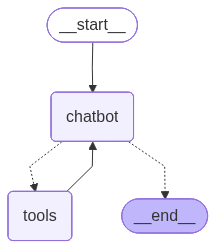

In [229]:
from IPython.display import display, Image, Markdown


display(Image(healthbuddy_agent.get_graph().draw_mermaid_png()))

## Inference

In [230]:
def call_conversational_agent(agent, prompt, user_session_id, verbose=False):
    events = agent.stream(
        {"messages": [{"role": "user", "content": prompt}]},
        {"configurable": {"thread_id": user_session_id}},
        stream_mode="values",
    )

    print('Running Agent. Please wait...')
    for event in events:
        if verbose:
            
            print(event["messages"][-1])

    display(Markdown(event["messages"][-1].content))

In [218]:

uid = 'subham001'
query = 'What doctors are available?'
call_conversational_agent(agent=healthbuddy_agent,
                          prompt=query,
                          user_session_id=uid,
                          verbose=True)

Running Agent. Please wait...
content='What doctors are available?' additional_kwargs={} response_metadata={} id='e9509368-209f-4a7f-b51d-f6ddb5e328b3'
content='' additional_kwargs={'tool_calls': [{'id': 'fc_0cd7df3f-19a8-4a61-82e7-0374c0ea3206', 'function': {'arguments': '{}', 'name': 'list_all_doctors'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 1066, 'total_tokens': 1116, 'completion_time': 0.107168946, 'prompt_time': 0.044857731, 'queue_time': 0.049471698, 'total_time': 0.152026677, 'completion_tokens_details': {'reasoning_tokens': 29}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ff6aa7708c', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-c389b1ab-34bd-4f6e-8aa0-ad90ad88d658-0' tool_calls=[{'name': 'list_all_doctors', 'args': {}, 'id': 'fc_0cd7df3f-19a8-4a61-82e7-0374c0ea3206', 'type': 'tool_call'}] usage_metadata={'input_tokens': 1066, 'output_tokens': 50, 'total_tokens': 1116}
content='[{\'name

Here’s the current list of doctors available at our clinic network:

| Doctor | Specialization | Available Timings | Location | Contact |
|--------|----------------|-------------------|----------|---------|
| **Dr. Janet Dyne** | Endocrinology (Diabetes Care) | 10:00 AM – 1:00 PM | City Health Clinic | janet.dyne@healthclinic.com |
| **Dr. Don Blake** | Cardiology (Heart Specialist) | 2:00 PM – 5:00 PM | Metro Cardiac Center | don.blake@metrocardiac.com |
| **Dr. Susan D'Souza** | Oncology (Cancer Care) | 11:00 AM – 2:00 PM | Hope Cancer Institute | susan.dsouza@hopecancer.org |
| **Dr. Matt Murdock** | Psychiatry (Mental Health) | 4:00 PM – 7:00 PM | Mind Care Center | matt.murdock@mindcare.com |
| **Dr. Dinah Lance** | General Physician | 9:00 AM – 12:00 PM | Downtown Medical Center | dinah.lance@downtownmed.com |

Let me know if you’d like more details about any of these doctors, want to see their available appointment slots, or would like to book an appointment.

In [219]:
uid = 'subham001'
query = "What doctors are available for panic attacks?"
call_conversational_agent(agent=healthbuddy_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
content='What doctors are available for panic attacks?' additional_kwargs={} response_metadata={} id='d7845320-6ab1-449f-a8fd-23e3b7125fe9'
content='' additional_kwargs={'tool_calls': [{'id': 'fc_06ffafc7-0f71-4af0-b869-1fe99af40e93', 'function': {'arguments': '{"query":"panic attacks"}', 'name': 'recommend_doctor'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 1714, 'total_tokens': 1792, 'completion_time': 0.16444016, 'prompt_time': 0.038042269, 'queue_time': 0.05318324, 'total_time': 0.202482429, 'prompt_tokens_details': {'cached_tokens': 1024}, 'completion_tokens_details': {'reasoning_tokens': 48}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e88ce9c728', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-190812f8-62cd-4531-a069-283c1e827bed-0' tool_calls=[{'name': 'recommend_doctor', 'args': {'query': 'panic attacks'}, 'id': 'fc_06ffafc7-0f71-4af0-b869-1fe99af40e93', 'type':

**Recommended Doctor for Panic Attacks**

| Doctor | Specialization | Available Timings | Location | Contact |
|--------|----------------|-------------------|----------|---------|
| **Dr. Matt Murdock** | Psychiatry (Mental Health) | 4:00 PM – 7:00 PM | Mind Care Center | matt.murdock@mindcare.com |

Dr. Murdock specializes in mental‑health conditions, including anxiety disorders and panic attacks.

Would you like to:

1. **View Dr. Murdock’s available appointment slots** and choose a time, or  
2. **Book an appointment directly** (if you already know a preferred slot)?

Please let me know how you’d like to proceed!

In [220]:
uid = 'subham001'
query = "Yes, please I would like to book an appointment immediately"
call_conversational_agent(agent=healthbuddy_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
content='Yes, please I would like to book an appointment immediately' additional_kwargs={} response_metadata={} id='736bb35b-6394-4fba-8b16-714974db5508'
content='' additional_kwargs={'tool_calls': [{'id': 'fc_84c7e6ab-0636-4487-bc41-e089247e75dc', 'function': {'arguments': '{"doctor_name":"Dr. Matt Murdock"}', 'name': 'show_available_slots'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 2001, 'total_tokens': 2101, 'completion_time': 0.217704061, 'prompt_time': 0.030780877, 'queue_time': 0.052883123, 'total_time': 0.248484938, 'prompt_tokens_details': {'cached_tokens': 1536}, 'completion_tokens_details': {'reasoning_tokens': 66}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ff6aa7708c', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-0a1e4036-e254-41fb-a8fb-34eb3d3e4f07-0' tool_calls=[{'name': 'show_available_slots', 'args': {'doctor_name': 'Dr. Matt Murdock'}, 'id': 'fc_84c

Here are the appointment slots currently open with **Dr. Matt Murdock** (Psychiatry – Mind Care Center):

| Slot |
|------|
| 4:00 PM |
| 4:30 PM |
| 5:00 PM |
| 5:30 PM |
| 6:00 PM |

Please reply with the **exact time** you’d like to book (e.g., “4:30 PM”). Once I have the slot, I’ll ask for your name, email, and phone number to complete the booking.

In [221]:
uid = 'subham001'
query = "Subham, subham001@gmail.com, 1001099"
call_conversational_agent(agent=healthbuddy_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
content='Subham, subham001@gmail.com, 1001099' additional_kwargs={} response_metadata={} id='a1bec83d-13c2-4235-8558-587cc3a82218'
content='I’m ready to finalize the booking, but I still need to know which **time slot** you’d like to reserve (e.g., “4:30\u202fPM”). Could you please let me know the exact slot you prefer from the list below?\n\n| Available Slots |\n|-----------------|\n| 4:00\u202fPM |\n| 4:30\u202fPM |\n| 5:00\u202fPM |\n| 5:30\u202fPM |\n| 6:00\u202fPM |\n\nOnce you confirm the slot, I’ll complete the appointment for **Subham** (subham001@gmail.com, phone\u202f1001099).' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 171, 'prompt_tokens': 2207, 'total_tokens': 2378, 'completion_time': 0.357920503, 'prompt_time': 0.036237159, 'queue_time': 0.0501608, 'total_time': 0.394157662, 'prompt_tokens_details': {'cached_tokens': 1536}, 'completion_tokens_details': {'reasoning_tokens': 34}}, 'model_name': 'openai/gpt-oss-

I’m ready to finalize the booking, but I still need to know which **time slot** you’d like to reserve (e.g., “4:30 PM”). Could you please let me know the exact slot you prefer from the list below?

| Available Slots |
|-----------------|
| 4:00 PM |
| 4:30 PM |
| 5:00 PM |
| 5:30 PM |
| 6:00 PM |

Once you confirm the slot, I’ll complete the appointment for **Subham** (subham001@gmail.com, phone 1001099).

In [222]:
uid = 'subham001'
query = "The 5 PM slot would be good"
call_conversational_agent(agent=healthbuddy_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
content='The 5 PM slot would be good' additional_kwargs={} response_metadata={} id='4d0a008c-6cb1-44eb-93b1-d375e025192b'
content='' additional_kwargs={'tool_calls': [{'id': 'fc_286ad500-05b3-4944-89e1-52a318596f68', 'function': {'arguments': '{"doctor_name":"Dr. Matt Murdock","email":"subham001@gmail.com","patient_name":"Subham","phone":"1001099","slot_time":"5:00 PM"}', 'name': 'book_appointment'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 2353, 'total_tokens': 2471, 'completion_time': 0.244008035, 'prompt_time': 0.061882217, 'queue_time': 0.053728062, 'total_time': 0.305890252, 'prompt_tokens_details': {'cached_tokens': 1024}, 'completion_tokens_details': {'reasoning_tokens': 45}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_1d1727abc9', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-dd18fb29-20d7-43fd-98bd-055c2658d1bb-0' tool_calls=[{'name': 'book_appointment', 'arg

**Appointment Confirmed**

| Patient | Doctor | Specialty | Date & Time | Location | Contact |
|---------|--------|-----------|-------------|----------|---------|
| Subham | Dr. Matt Murdock | Psychiatry (Mental Health) | **5:00 PM** (today) | Mind Care Center | matt.murdock@mindcare.com |

**Details**
- **Patient Name:** Subham  
- **Email:** subham001@gmail.com  
- **Phone:** 1001099  

If you need to reschedule, cancel, or have any other questions, just let me know!

In [223]:
bookings_db

[{'patient_name': 'Subham',
  'email': 'subham001@gmail.com',
  'phone': '1001099',
  'doctor_name': 'Dr. Matt Murdock',
  'slot': '5:00 PM'}]

In [231]:
doctor_slots_db['Dr. Matt Murdock']

{'slots': [{'time': '4:00 PM', 'available': True},
  {'time': '4:30 PM', 'available': True},
  {'time': '5:00 PM', 'available': False},
  {'time': '5:30 PM', 'available': True},
  {'time': '6:00 PM', 'available': True}]}